## Using Combinations of Different Observable Constraints to Determine the Lens Mass and Distance for a Microlensing Event

### Combination 1: $\theta_E$ and $\pi_E$

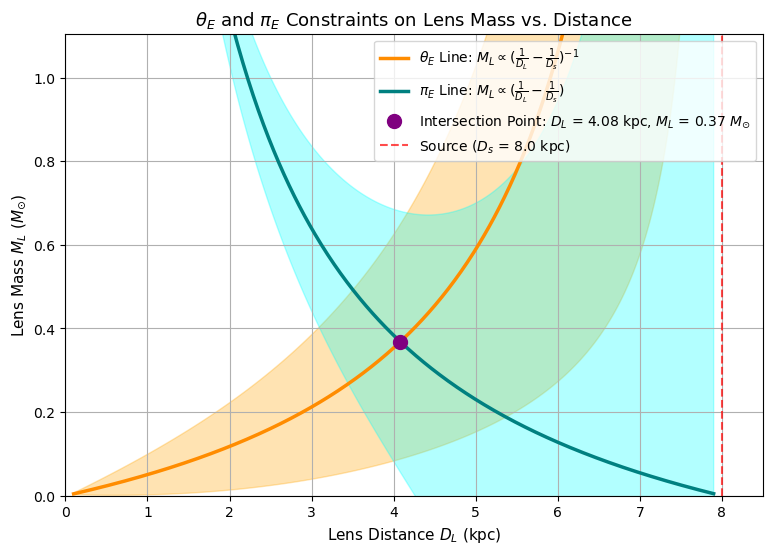

In [74]:
import numpy as np
import matplotlib.pyplot as plt

# Constants & Parameters
D_s = 8.0        # Distance to the source star (kpc)
kappa = 8.144    # Microlensing constant (mas / M_sun)

# values of observables
theta_E = 0.6    # Angular Einstein radius (mas)
pi_E = 0.2       # Microlens parallax

M_L = np.linspace(0.01, 2.0, 500)
D_L = np.linspace(0.1, D_s - 0.1, 500)

# uncertainties
sigma_D_s = 0.1 * D_s  # 10% uncertainty in source distance
sigma_D_L = 0.1 * D_L  # 10% uncertainty in lens distance (assuming we don't know it)
sigma_theta_E = 0.1 * theta_E  # 10% uncertainty in theta_E
sigma_pi_E = 0.1 * pi_E  # 10% uncertainty in pi_E

# theta_E constraint
M_L_theta = ((theta_E**2) / (kappa)) * (D_s * D_L / (D_s - D_L))
# pi_E constraint 
M_L_pi = ((D_s - D_L) / (D_s * D_L)) * (1 / (kappa * pi_E**2))

# uncertainties in mass
sigma_M_L_theta_E = M_L * ((2 * sigma_theta_E / theta_E)**2 + (sigma_D_s)**2 * ((1 / D_s) - (1 / (D_s - D_L)))**2 + (sigma_D_L)**2 * ((1 / D_s + 1 / (D_s - D_L)))**2)**0.5
sigma_M_L_pi_E = M_L * ((2 * sigma_pi_E / pi_E)**2 + (sigma_D_L)**2 * ((-1 / (D_s - D_L)) - (1 / D_L))**2 + (sigma_D_s)**2 * ((-1 / D_s) + (1 / (D_s - D_L)))**2)**0.5

# Intersection Point
D_L_intersect = 1.0 / (pi_E * theta_E + (1.0 / D_s))
M_L_intersect = theta_E / (kappa * pi_E)

# Plotting to constrain M_L and D_L
plt.figure(figsize=(9, 6))

# Plot theta_E line
plt.plot(D_L, M_L_theta, color='darkorange', linewidth=2.5, 
         label=r'$\theta_E$ Line: $M_L \propto (\frac{1}{D_L} - \frac{1}{D_s})^{-1}$')
plt.fill_between(D_L, M_L_theta - sigma_M_L_theta_E, M_L_theta + sigma_M_L_theta_E, color='orange', alpha=0.3)

# Plot pi_E line
plt.plot(D_L, M_L_pi, color='teal', linewidth=2.5, 
        label=r'$\pi_E$ Line: $M_L \propto (\frac{1}{D_L} - \frac{1}{D_s})$')
plt.fill_between(D_L, M_L_pi - sigma_M_L_pi_E, M_L_pi + sigma_M_L_pi_E, color='cyan', alpha=0.3)

# Plot intersection point
plt.scatter(D_L_intersect, M_L_intersect, color='purple', s=100, zorder=5, label='Intersection Point: $D_L$ = {:.2f} kpc, $M_L$ = {:.2f} $M_{{\odot}}$'.format(D_L_intersect, M_L_intersect))

# Graph labels
plt.title(r'$\theta_E$ and $\pi_E$ Constraints on Lens Mass vs. Distance', fontsize=13)
plt.xlabel('Lens Distance $D_L$ (kpc)', fontsize=11)
plt.ylabel('Lens Mass $M_L$ ($M_{\odot}$)', fontsize=11)

# Plot D_s line
plt.axvline(x=D_s, color='red', linestyle='--', alpha=0.7, label=f'Source ($D_s$ = {D_s} kpc)')

# Adjusting limits to see intersection clearly
plt.xlim(0, D_s + 0.5)
plt.ylim(0, M_L_intersect * 3.0)
plt.grid()
plt.legend(loc='upper right')

plt.show()

### Combination 2: $\theta_E$ and $F_{L}$

In [ ]:
#code for theta e and FL

### Combination 3: $\pi_E$ and $F_{L}$

In [ ]:
#code

### Combination 4: $\theta_E$ and $D_{L}$

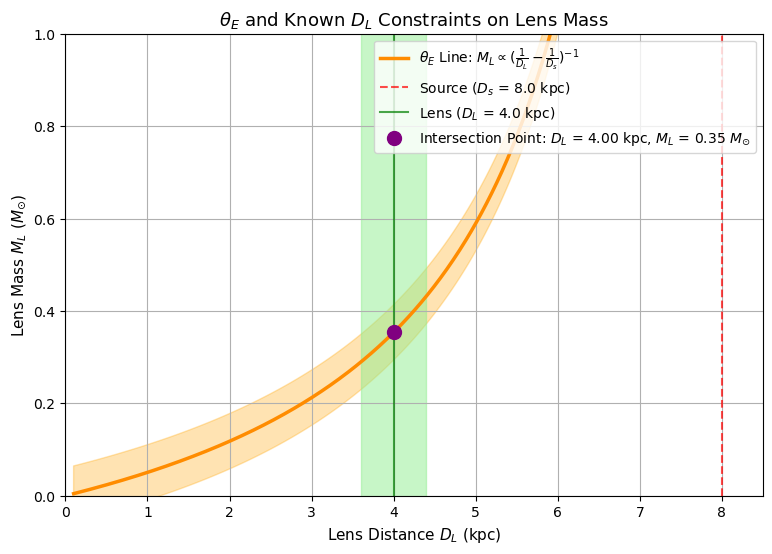

In [77]:
import numpy as np
import matplotlib.pyplot as plt

# Constants & Parameters
D_s = 8.0        # Distance to the source star (kpc)      
D_L_known = 4.0  # Known distance to the lens (kpc)
kappa = 8.144    # Microlensing constant (mas / M_sun)

# values of observables
theta_E = 0.6    # Angular Einstein radius (mas)

# uncertainties
sigma_D_L_known = 0.1 * D_L_known  # 10% uncertainty in known lens distance
sigma_D_s = 0.1 * D_s  # 10% uncertainty in source distance
sigma_theta_E = 0.1 * theta_E  # 10% uncertainty in theta_E

M_L = np.linspace(0.01, 2.0, 500)
D_L = np.linspace(0.1, D_s - 0.1, 500)

# theta_E constraint
M_L_theta = ((theta_E**2) / (kappa)) * (D_s * D_L / (D_s - D_L))

# uncertainties in mass (assuming 10%)
sigma_M_L_theta_E = M_L * ((2 * sigma_theta_E / theta_E)**2 + (sigma_D_s)**2 * ((1 / D_s) - (1 / (D_s - D_L_known))**2 + (sigma_D_L_known)**2 * ((1 / D_s + 1 / (D_s - D_L_known)))**2))**0.5
sigma_D_L_known = 0.1 * D_L_known  # 10% uncertainty in known lens distance

# Intersection Point
D_L_intersect = D_L_known
M_L_intersect = ((theta_E**2) / (kappa)) * (D_s * D_L_intersect / (D_s - D_L_intersect))

# Plotting to constrain M_L and D_L
plt.figure(figsize=(9, 6))

# Plot theta_E line
plt.plot(D_L, M_L_theta, color='darkorange', linewidth=2.5, 
         label=r'$\theta_E$ Line: $M_L \propto (\frac{1}{D_L} - \frac{1}{D_s})^{-1}$')
plt.fill_between(D_L, M_L_theta - sigma_theta_E, M_L_theta + sigma_theta_E, color='orange', alpha=0.3)

# Graph labels
plt.title(r'$\theta_E$ and Known $D_L$ Constraints on Lens Mass', fontsize=13)
plt.xlabel('Lens Distance $D_L$ (kpc)', fontsize=11)
plt.ylabel('Lens Mass $M_L$ ($M_{\odot}$)', fontsize=11)

# Plot D_s and known D_L lines
plt.axvline(x=D_s, color='red', linestyle='--', alpha=0.7, label=f'Source ($D_s$ = {D_s} kpc)')
plt.axvline(x=D_L_known, color='green', alpha=0.7, label=f'Lens ($D_L$ = {D_L_known} kpc)')
plt.fill_betweenx([-1, 5], D_L_known - sigma_D_L_known, D_L_known + sigma_D_L_known, color='lightgreen', alpha=0.5)

# Plot intersection point
plt.scatter(D_L_intersect, M_L_intersect, color='purple', s=100, zorder=5, label='Intersection Point: $D_L$ = {:.2f} kpc, $M_L$ = {:.2f} $M_{{\odot}}$'.format(D_L_intersect, M_L_intersect))

# Adjusting limits to see intersection clearly
plt.xlim(0, D_s + 0.5)
plt.ylim(0, 1)
plt.grid()
plt.legend(loc='upper right')

plt.show()

### Combination 5: $\pi_E$ and $D_{L}$

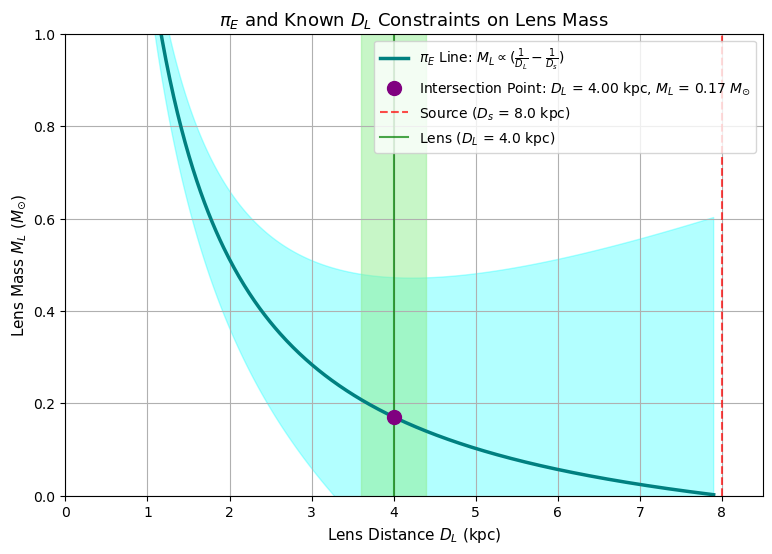

In [76]:
import numpy as np
import matplotlib.pyplot as plt

# Constants & Parameters
D_s = 8.0        # Distance to the source star (kpc)      
D_L_known = 4.0  # Known distance to the lens (kpc)
kappa = 8.144    # Microlensing constant (mas / M_sun)

# values of observables
pi_E = 0.3    # Angular Einstein radius (mas)

# uncertainties
sigma_D_L_known = 0.1 * D_L_known  # 10% uncertainty in known lens distance
sigma_D_s = 0.1 * D_s  # 10% uncertainty in source distance
sigma_pi_E = 0.1 * pi_E  # 10% uncertainty in pi_E

M_L = np.linspace(0.01, 2.0, 500)
D_L = np.linspace(0.1, D_s - 0.1, 500)

# pi_E constraint 
M_L_pi = ((D_s - D_L) / (D_s * D_L)) * (1 / (kappa * pi_E**2))

# uncertainties in mass (assuming 10%)
sigma_M_L_pi_E = M_L * ((2 * sigma_pi_E / pi_E)**2 + (sigma_D_L_known)**2 * ((-1 / (D_s - D_L_known)) - (1 / D_L_known))**2 + (sigma_D_s)**2 * ((-1 / D_s) + (1 / (D_s - D_L_known)))**2)**0.5

# Intersection Point
D_L_intersect = D_L_known
M_L_intersect = ((D_s - D_L_intersect) / (D_s * D_L_intersect)) * (1 / (kappa * pi_E**2))

# Plotting to constrain M_L and D_L
plt.figure(figsize=(9, 6))

# Plot pi_E line
plt.plot(D_L, M_L_pi, color='teal', linewidth=2.5, 
        label=r'$\pi_E$ Line: $M_L \propto (\frac{1}{D_L} - \frac{1}{D_s})$')
plt.fill_between(D_L, M_L_pi - sigma_M_L_pi_E, M_L_pi + sigma_M_L_pi_E, color='cyan', alpha=0.3)

# Plot intersection point
plt.scatter(D_L_intersect, M_L_intersect, color='purple', s=100, zorder=5, label='Intersection Point: $D_L$ = {:.2f} kpc, $M_L$ = {:.2f} $M_{{\odot}}$'.format(D_L_intersect, M_L_intersect))

# Graph labels
plt.title(r'$\pi_E$ and Known $D_L$ Constraints on Lens Mass', fontsize=13)
plt.xlabel('Lens Distance $D_L$ (kpc)', fontsize=11)
plt.ylabel('Lens Mass $M_L$ ($M_{\odot}$)', fontsize=11)

# Plot D_s and known D_L lines
plt.axvline(x=D_s, color='red', linestyle='--', alpha=0.7, label=f'Source ($D_s$ = {D_s} kpc)')
plt.axvline(x=D_L_known, color='green', alpha=0.7, label=f'Lens ($D_L$ = {D_L_known} kpc)')
plt.fill_betweenx([-1, 5], D_L_known - sigma_D_L_known, D_L_known + sigma_D_L_known, color='lightgreen', alpha=0.5)

# Adjusting limits to see intersection clearly
plt.xlim(0, D_s + 0.5)
plt.ylim(0, 1)
plt.grid()
plt.legend(loc='upper right')

plt.show()

### Combination 6: $F_{L}$ and $D_{L}$

In [ ]:
#code